In [43]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [44]:
(x_train, y_train),(x_test, y_test) = keras.datasets.mnist.load_data()

In [45]:
x_train.shape

(60000, 28, 28)

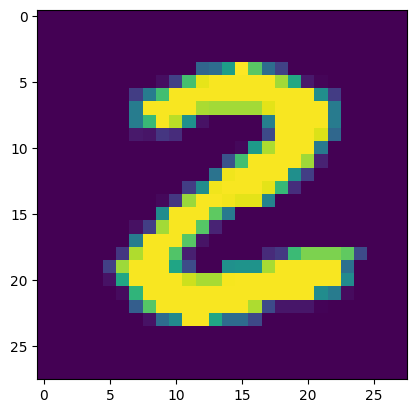

In [46]:
import matplotlib.pyplot as plt

plt.imshow(x_train[25])

allways convert the numbers into similar range

In [47]:
x_train = x_train/255
x_test = x_test/255

In [48]:
model = Sequential()
model.add(Flatten(input_shape = (28, 28)))
model.add(Dense(128, activation = "relu"))
model.add(Dense(10, activation = "softmax"))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [49]:
model.compile(optimizer = "Adam", loss = "sparse_categorical_crossentropy")

In [50]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.fit(x_train, y_train, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2636
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1165
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0799
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0609
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0472
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0369
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0297
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0245
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0202
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0180


In [57]:
pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [58]:
pred

array([[1.6632503e-08, 9.0859351e-12, 4.4932605e-08, ..., 9.9997723e-01,
        9.5363793e-11, 8.3720657e-08],
       [1.9687481e-13, 1.3128656e-09, 1.0000000e+00, ..., 7.9801158e-17,
        3.0899679e-11, 4.3943909e-20],
       [1.2517147e-09, 9.9139053e-01, 5.2988187e-05, ..., 1.0417459e-03,
        7.4629248e-03, 3.3620651e-07],
       ...,
       [2.0806080e-19, 6.3940921e-13, 2.9025174e-15, ..., 7.7118611e-10,
        1.5192297e-11, 3.4096900e-08],
       [6.3866347e-12, 9.7157545e-14, 6.1929547e-14, ..., 3.8312973e-13,
        2.2317575e-04, 1.4151548e-14],
       [2.5177083e-12, 2.2142838e-16, 8.0769488e-11, ..., 1.1504285e-12,
        1.5443665e-12, 3.3925455e-15]], dtype=float32)

In [64]:
pred.shape

(10000, 10)

In [66]:
pred_1 = pred.argmax(axis = 1)
pred_1

array([7, 2, 1, ..., 4, 5, 6])

In [67]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred_1)

0.9803